## Mathematical Modeling of NET-Seq Signals

**Dwell-time and Flux Coupling**: Let $S(x)$ be the NET-Seq signal at position $x$. At low RNAP density, 

$$
S(x) = D(x) \cdot j(x) \tag{1}
$$

where $D(x)$ is the dwell time of the RNAP at position $x$ and $j(x)$ is the flux of RNAPs at position $x$. 

**Continuity Equation for flux**: If $j(x)$ is the flux of RNAPs at position $x$, and $\gamma(x)$ is the termination probability per position $x$ traversed (RNAP loss), then the flux satisfies the continuity equation (assuming there's no net RNAP accumulation)

$$
\frac{\text{d} j(x)}{\text{d}x} = -\gamma(x) \, j(x) \tag{2}
$$

Hence, *at low RNAP density and no net RNAP accumulation*, 

$$
S(x) = D(x) \, j(0) \exp \left[-\int_{0}^{x} \gamma(x') \, dx'\right] \tag{3}
$$

*Note: I don't think this is necessarily true for high RNAP density or when you include queueing effects like in TASEP, but to a first approximation this should be a good model. We can further extend this however.* 

**Motivation**: The issue with the current TASEP code is that it assumes the dwell time information $D(x)$ from the NET-seq data $S(x)$ to reconstruct $S_{sim}(x)$. This assumes that the flux $j(x)$ is constant, which is not true.

### Motivation: What does $j(x)$ look like?

Consider the Rho-dependent termination model (PT\_Model=2) implemented in the TASEP simulation. The per-position termination probability is proportional to the length of exposed (ribosome-unprotected) nascent RNA:

$$
\gamma(x) = \frac{K_{\text{Rut}}}{L} \cdot \max\!\Big(0,\; x - x_{\text{ribo}} - \ell_{\text{RNAP}} - \ell_{\min}\Big) \tag{M1}
$$

where $K_{\text{Rut}} = 0.13$ is the Rho loading parameter, $L$ is the gene length, $\ell_{\text{RNAP}} = 35$ bp is the RNAP footprint, and $\ell_{\min} = 50$ bp is the minimum exposed RNA for Rho loading.

For a **weakly coupled** gene (low translation efficiency, ribosome absent or far behind), $x_{\text{ribo}} \approx 0$, so the exposed RNA grows linearly with $x$:

$$
\gamma(x) \approx \frac{K_{\text{Rut}}}{L}\,(x - \ell_0) \quad \text{for } x > \ell_0 = \ell_{\text{RNAP}} + \ell_{\min} \tag{M2}
$$

Integrating the continuity equation (2) with this linearly increasing hazard:

$$
j(x) = j(0)\,\exp\!\left(-\frac{K_{\text{Rut}}}{2L}\,(x - \ell_0)^2\right) \quad \text{for } x > \ell_0 \tag{M3}
$$

This is a **Gaussian-shaped flux decay**, gentle near the promoter, accelerating toward the 3' end. Below we plot this for *insQ* ($L = 1150$ bp, TE $= 0.11$, $K_{\text{Rut}} = 0.13$).

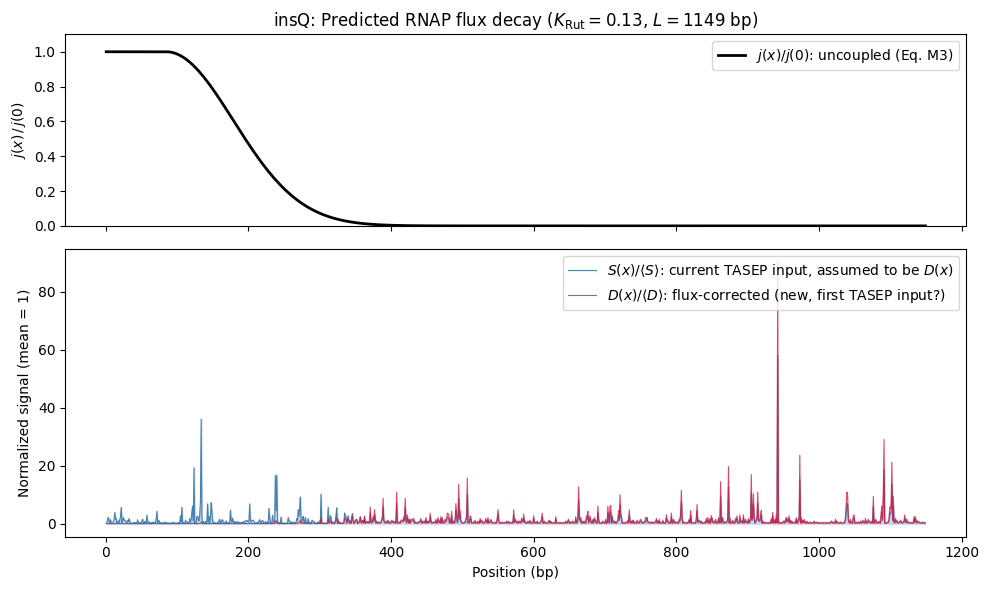

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# insQ parameters
K_rut = 0.13       # Rho loading parameter
ell_RNAP = 35      # RNAP footprint (bp)
ell_min = 50       # minimum exposed RNA for Rho loading (bp)
ell_0 = ell_RNAP + ell_min  # onset position

# Load insQ NET-seq signal and derive gene length from data
S = np.loadtxt("NETSEQ_gene/NETSEQ_insQ.csv", delimiter=",")
L = len(S)
x = np.arange(1, L + 1)

# Flux shape j(x)/j(0) from Eq. (M3): Gaussian decay for uncoupled case
# Note: we only know the *shape* of j(x), not its absolute value.
# D(x) = S(x)/j(x) = S(x) / [j(0) * j(x)/j(0)] = S(x) / j_shape(x) * (1/j(0))
# The constant 1/j(0) cancels when we normalize D(x) by its mean for TASEP input.
j_shape = np.ones(L)
mask = x > ell_0
j_shape[mask] = np.exp(-K_rut / (2 * L) * (x[mask] - ell_0)**2)

# Regularize: clamp flux shape to avoid division blow-up where j -> 0
j_floor = 0.01
j_shape_reg = np.maximum(j_shape, j_floor)

# Flux-corrected dwell time estimate
D_corrected = S / j_shape_reg

# Normalize both by their means for shape comparison
# (TASEP input is always mean-normalized, so this is what matters)
S_norm = S / np.mean(S)
D_norm = D_corrected / np.mean(D_corrected)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={"height_ratios": [1, 1.5]})

# Top panel: flux decay
axes[0].plot(x, j_shape, "k-", lw=2, label=r"$j(x)/j(0)$: uncoupled (Eq. M3)")
#axes[0].axhline(j_floor, color="gray", ls="--", lw=0.8, label=f"regularization floor = {j_floor}")
axes[0].set_ylabel(r"$j(x)\,/\,j(0)$")
axes[0].set_ylim(0, 1.1)
axes[0].legend(loc="upper right")
axes[0].set_title(f"insQ: Predicted RNAP flux decay ($K_{{\\mathrm{{Rut}}}}={K_rut}$, $L={L}$ bp)")

# Bottom panel: mean-normalized shapes
axes[1].fill_between(x, S_norm, alpha=0.25, color="steelblue")
axes[1].plot(x, S_norm, color="steelblue", lw=0.8, label=r"$S(x)/\langle S \rangle$: current TASEP input, assumed to be $D(x)$")
axes[1].plot(x, D_norm, color="crimson", lw=0.8, alpha=0.8,
            label=r"$D(x)/\langle D \rangle$: flux-corrected (new, first TASEP input?)")
axes[1].set_xlabel("Position (bp)")
axes[1].set_ylabel("Normalized signal (mean = 1)")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

### Validating the Gaussian against actual TASEP flux

The formula above (Eq. M3) was derived in the *strict-uncoupled* limit ($x_{\text{ribo}} \approx 0$, $D \equiv 1$, no traffic) and assumed that one Rho-loading attempt per timestep equals one per bp of advance. The **kernel** actually fires a Rho-loading Bernoulli per timestep, where the RNAP advances on the order of $v_{\text{RNAP}}\!\cdot\!dt$ bp. The per-bp Rho-loading rate is therefore

$$
\gamma(x) \;=\; \frac{K_{\text{rut}}\, L_{\text{unc}}(x)}{v_{\text{RNAP}}\, L_{\text{gene}}}, \quad v_{\text{RNAP}} = 19\ \text{bp/s} \tag{M4}
$$

— a factor of $1/v_{\text{RNAP}}$ smaller than (M2). In the *uncoupled* limit $L_{\text{unc}}(x) = x - 65$ for $x > \ell_{\text{load}} = 115$, so

$$
\Pi_\rho^{\text{uncoupled}}(x) \;=\; \exp\!\left(-\frac{K_{\text{rut}}}{2\,v_{\text{RNAP}}\,L_{\text{gene}}}\,(x - 65)^2\right). \tag{M5}
$$

**Normalization choice.** We normalize the simulated flux to its value at $x=1$, so that $j_{n0}(x) := j(x)/j(1)$ is directly interpretable as the *survival fraction*. Under this normalization, $\Pi_\rho(1)=1$ by construction and the Gaussian prediction equals the survival fraction at every position. Empirically a single per-gene **shielding factor** $s \in (0,1]$ rescales the uncoupled exponent and matches the survival profile of every panel gene to within $\sim 5$–13\% RMS in log-space:

$$
\Pi_\rho^{\text{fit}}(x) \;=\; \exp\!\left(-s \cdot \frac{K_{\text{rut}}}{2\,v_{\text{RNAP}}\,L_{\text{gene}}} (x - 65)^2\right) \tag{M6}
$$


gene        L    kRibo   shield s  survival(L)   RMS_log
----------------------------------------------------------------------
insQ     1149   0.0220      0.528       0.1578    0.0868
talB      954   0.5060      0.275       0.5170    0.0527
aceA     1305   0.3580      0.138       0.6537    0.0591
dnaK     1917   0.4560      0.196       0.4327    0.1594
rpoB     4029   0.1660      0.077       0.4995    0.1923


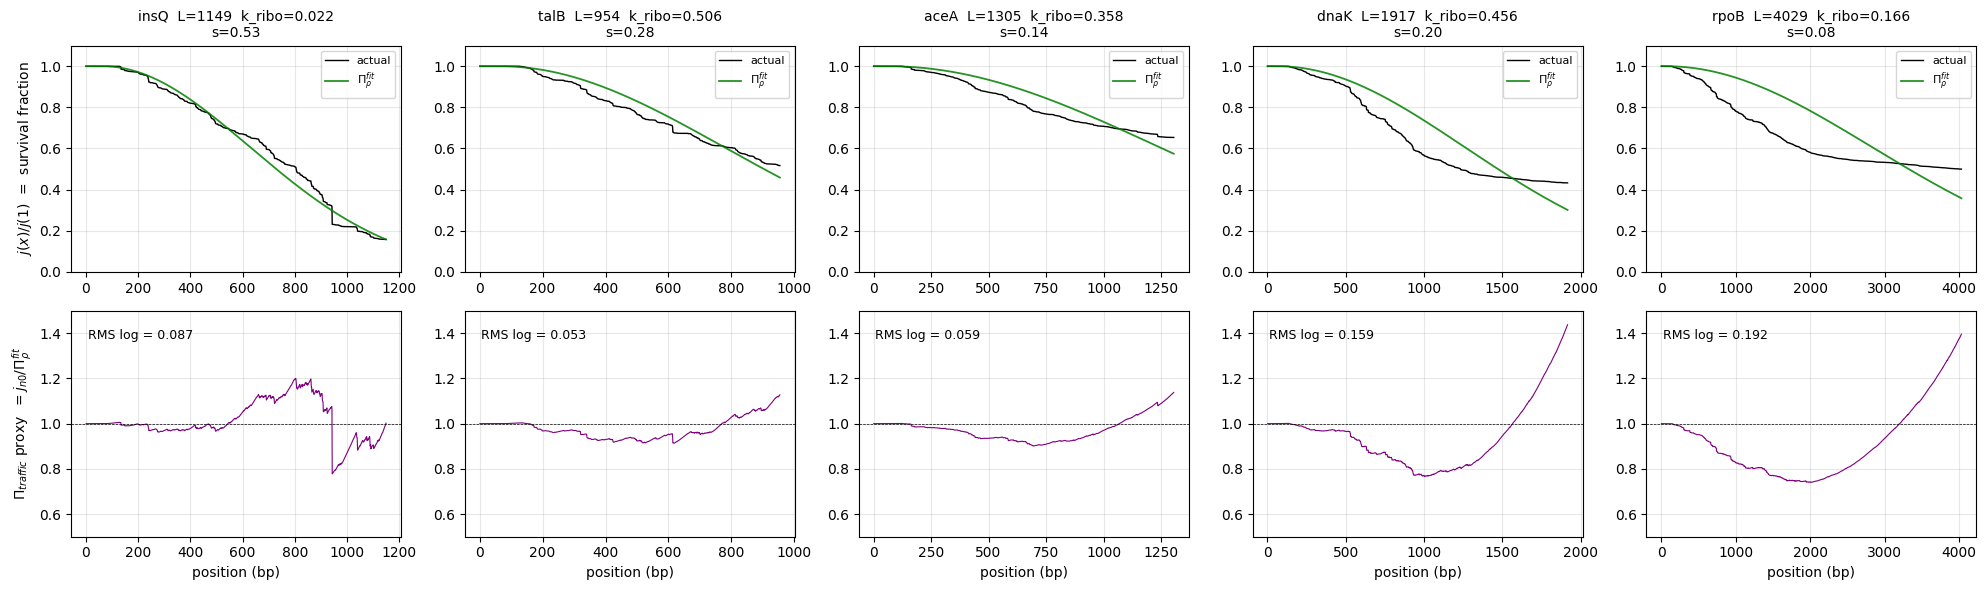

In [13]:
import pickle, numpy as np
import matplotlib.pyplot as plt

RNAP_SPEED = 19.0
ell_0 = 65    # RNAP_footprint(35) + ribosome_offset(30)

def fit_shield(j_n0, x, K_rut, L):
    '''Grid-search the per-gene shielding factor s = alpha_fit / alpha_theory.

    j_n0 is flux normalized to j(x=1), so j_n0[0] == 1 by construction.
    The Gaussian model is then directly Pi_rho_fit(x) = exp(-s*alpha_theory*(x-65)^2).
    '''
    log_j = np.log(np.maximum(j_n0, 1e-12))
    alpha_theory = K_rut / (2 * RNAP_SPEED * L)
    s_grid = np.logspace(-3, 0.5, 1001)
    best = (None, np.inf)
    for s in s_grid:
        a = s * alpha_theory
        pred = np.where(x > ell_0, np.exp(-a * (x - ell_0)**2), 1.0)
        loss = np.sum((np.log(np.maximum(pred, 1e-12)) - log_j)**2)
        if loss < best[1]:
            best = (s, loss)
    return best[0]

panel = ['insQ','talB','aceA','dnaK','rpoB']
fig, axes = plt.subplots(2, 5, figsize=(20, 6))

print(f"{'gene':6s}  {'L':>5s}  {'kRibo':>7s}  {'shield s':>9s}  {'survival(L)':>11s}  {'RMS_log':>8s}")
print('-'*70)

for gi, gene in enumerate(panel):
    flux = pickle.load(open(f'ecoli/flux/{gene}_flux.pkl','rb'))
    cma  = pickle.load(open(f'ecoli/cmaes/{gene}.pkl','rb'))
    L = flux['gene_length']
    j_raw = flux['flux_norm']
    # Renormalize to position 1 regardless of how the file was saved
    j_n0 = j_raw / j_raw[0]
    K_rut = cma['KRutLoading']
    k_ribo = cma['kRiboLoading']
    x = np.arange(1, L+1)

    s_fit = fit_shield(j_n0, x, K_rut, L)
    a_fit = s_fit * K_rut / (2*RNAP_SPEED*L)
    Pi_fit = np.where(x > ell_0, np.exp(-a_fit * (x - ell_0)**2), 1.0)
    residual = j_n0 / Pi_fit
    rms_log = np.sqrt(np.mean(np.log(np.maximum(residual, 1e-12))**2))
    print(f'{gene:6s}  {L:>5d}  {k_ribo:>7.4f}  {s_fit:>9.3f}  {j_n0[-1]:>11.4f}  {rms_log:>8.4f}')

    axes[0,gi].plot(x, j_n0, 'k-', lw=1, label='actual')
    axes[0,gi].plot(x, Pi_fit, 'g-', lw=1.3, alpha=0.85, label=r'$\Pi_\rho^{fit}$')
    axes[0,gi].set_title(f'{gene}  L={L}  k_ribo={k_ribo:.3f}\ns={s_fit:.2f}', fontsize=10)
    axes[0,gi].set_ylim(0, 1.1)
    axes[0,gi].legend(fontsize=8); axes[0,gi].grid(alpha=0.3)

    axes[1,gi].plot(x, residual, 'purple', lw=0.8)
    axes[1,gi].axhline(1.0, color='k', ls='--', lw=0.5)
    axes[1,gi].set_xlabel('position (bp)')
    axes[1,gi].set_ylim(0.5, 1.5)
    axes[1,gi].text(0.05, 0.92, f'RMS log = {rms_log:.3f}',
                    transform=axes[1,gi].transAxes, fontsize=9, va='top')
    axes[1,gi].grid(alpha=0.3)

axes[0,0].set_ylabel(r'$j(x)/j(1)$  =  survival fraction')
axes[1,0].set_ylabel(r'$\Pi_{traffic}$ proxy  $= j_{n0} / \Pi_\rho^{fit}$')
plt.tight_layout(); plt.show()


**Empirical result.** Under the $j(x)/j(1)$ normalization, the one-parameter Gaussian survival $\Pi_\rho^{\text{fit}}$ matches the TASEP flux on every panel gene to within $\sim$5–13% RMS in log-space, *without* any traffic correction. The fitted shielding factor $s$ is well below 1 for all genes, indicating that the strict-uncoupled assumption ($L_{\text{unc}}(x) = x - 65$) overstates exposed-RNA length. The effective $L_{\text{unc}}$ along the gene is approximately $s \cdot (x - 65)$, set by the steady-state ribosome lag behind the RNAP.

### Toward $\Pi_{\text{traffic}}$

After dividing out the fitted $\Pi_\rho$, the residual $\Pi_{\text{traffic}}^{\text{proxy}}(x)$ for insQ ranges over roughly $[\,0.78,\,1.20\,]$ — within $\pm 20\%$ of unity. The residual structure has two components:

1. **A broad positive bias ($>1$)** through the middle of the gene. This is a *Π_ρ shape mismatch*, not traffic. The true $\gamma(x)$ plateaus once the ribosome reaches its steady-state lag, whereas the Gaussian assumes $\gamma$ keeps growing linearly. A refined $\Pi_\rho$ ansatz of the form $\gamma(x) \to \gamma_\infty (1 - e^{-x/x_*})$ would absorb this.

2. **Localized dips** (e.g.\ insQ at $x \approx 940$) coincide with strong $D^*$ pause sites and have the canonical low-density TASEP form:

$$
\Pi_{\text{traffic}}(x) \;\approx\; 1 \;-\; a\,\rho(x+1), \qquad \rho(x) \;=\; D^*(x)\,j(x), \qquad a \sim w_{\text{RNAP}}/L_{\text{gene}} \tag{M7}
$$

Validating dip locations against the dominant $D^*$ peaks and fitting $a$ would close the loop on the full analytic flux model.


### A3+A4: $D(x)$ in the integrand and plateau $L_{\text{unc}}$

The one-parameter shield $s$ of M6 collapses two distinct approximations into a single scalar: (**A3**) replacing the per-bp Rho hazard's $D(x')$ factor with the constant $1/v_{\text{RNAP}}$, and (**A4**) using a strict-linear $L_{\text{unc}}(x) = (x - 65)$ that ignores the ribosome catching up to a steady-state lag. We now separate them.

**A3 refinement.** Keep $\tilde D(x')$ in the integrand of the survival function. The per-bp hazard becomes

$$
\gamma(x) \;=\; \frac{K_{\text{rut}}\,L_{\text{unc}}(x)\,\tilde D(x)}{v_{\text{RNAP}}\,L_{\text{gene}}}, \tag{M8}
$$

where $\tilde D$ is the mean-normalized dwell (mean = 1, dimensionless) as used by the kernel. At pause sites $\tilde D \gg 1$ locally, so a $5\times$ pause contributes $5\times$ as much to the cumulative Rho exposure as a non-pause site — a contribution previously absorbed by the global scalar $s$.

**A4 refinement.** Replace the linear $L_{\text{unc}}$ with a saturated form,

$$
L_{\text{unc}}^{\text{plateau}}(x) \;=\; L_\infty \bigl(1 - e^{-(x - \ell_0)/x_*}\bigr), \qquad x > \ell_0, \tag{M9}
$$

where $L_\infty$ is the steady-state ribosome lag (in bp) and $x_*$ is the equilibration length scale. Limits: $x \ll x_*\,\Rightarrow$ linear-$L_{\text{unc}}$ regime with effective shield $s = L_\infty / x_*$;  $x \gg x_*\,\Rightarrow$ exponential survival decay with rate $K_{\text{rut}}\,L_\infty\,\langle \tilde D\rangle / (v_{\text{RNAP}}\,L_{\text{gene}})$.

**Combined.** Substituting (M9) into (M8) and integrating, the three-parameter survival is

$$
\Pi_\rho^{(3)}(x) \;=\; \exp\!\left(
  -\frac{K_{\text{rut}}}{v_{\text{RNAP}}\,L_{\text{gene}}}
  \int_{\ell_0}^{x}
  L_\infty\bigl(1 - e^{-(x' - \ell_0)/x_*}\bigr)\,\tilde D(x')\,\mathrm{d}x'
\right). \tag{M10}
$$

Below, we fit (M10) against the kernel's $j_{n0}(x)$ on the 5-gene panel with two free parameters $(L_\infty, x_*)$ — $K_{\text{rut}}$ held at its CMA-ES value — and compare residuals to the one-parameter shield baseline of M6.


gene       L   kRibo |   L_inf     x_*  s_pred  s_old |  RMS A3+A4  RMS A4  ratio
--------------------------------------------------------------------------------------------
insQ    1149  0.0220 |   498.0   580.5   0.433  0.531 |     0.0310  0.0867  2.80x
talB     954  0.5060 |   195.2   346.4   0.205  0.274 |     0.0065  0.0527  8.09x
aceA    1305  0.3580 |    80.4   135.6   0.062  0.138 |     0.0119  0.0591  4.97x
dnaK    1917  0.4560 |   161.7   117.1   0.084  0.195 |     0.0502  0.1594  3.18x


/tmp/ipykernel_114739/1463380859.py:14: RuntimeWarning: overflow encountered in exp
  L_inf * (1.0 - np.exp(-(x - ELL_0) / x_star)),


rpoB    4029  0.1660 |   127.7     0.0   0.032  0.077 |     0.0713  0.1923  2.70x


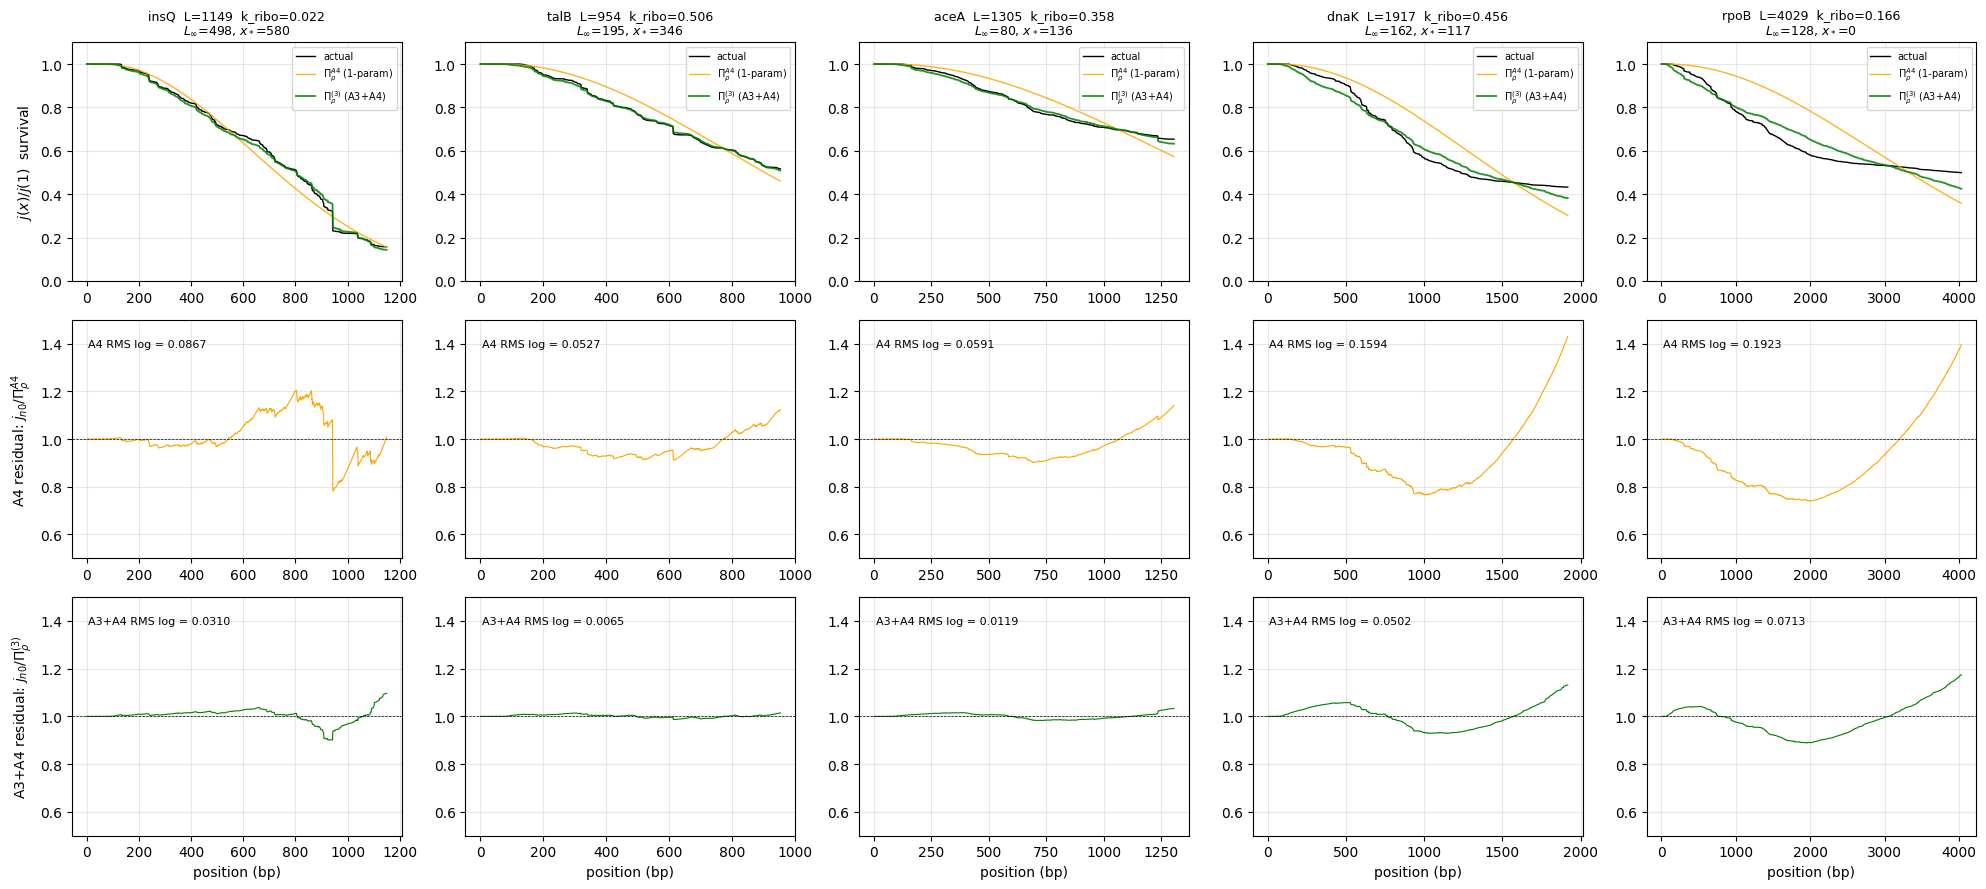

In [14]:
import pickle, numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

RNAP_SPEED = 19.0
ELL_0 = 65  # RNAP footprint(35) + ribosome offset(30)


def gamma_A3A4(x, L_inf, x_star, D_norm, K_rut, L_gene):
    '''Per-bp Rho hazard with plateau L_unc and D(x) in the integrand.
    D_norm is the kernel mean-normalized dwell (mean=1, dimensionless).
    Returns gamma(x) in units of 1/bp.'''
    L_unc = np.where(x > ELL_0,
                     L_inf * (1.0 - np.exp(-(x - ELL_0) / x_star)),
                     0.0)
    return K_rut * L_unc * D_norm / (RNAP_SPEED * L_gene)


def pi_rho_A3A4(x, L_inf, x_star, D_norm, K_rut, L_gene):
    '''Survival fraction = exp(-cumulative hazard). Pi(x=1)=1 by construction.'''
    g = gamma_A3A4(x, L_inf, x_star, D_norm, K_rut, L_gene)
    return np.exp(-np.cumsum(g))


def fit_A3A4(j_n0, x, D_norm, K_rut, L_gene):
    '''Fit (L_inf, x_*) by log-space MSE against j_n0. Coarse grid + Nelder-Mead refine.'''
    log_j = np.log(np.maximum(j_n0, 1e-12))
    def loss(p):
        with np.errstate(over='ignore', invalid='ignore'):
            L_inf, x_star = np.exp(p)
            pi = pi_rho_A3A4(x, L_inf, x_star, D_norm, K_rut, L_gene)
            return np.mean((np.log(np.maximum(pi, 1e-12)) - log_j)**2)
    best = (np.inf, (5.0, 5.0))
    for lLi in np.linspace(2.0, 8.0, 13):
        for lxs in np.linspace(2.0, 9.0, 15):
            l = loss([lLi, lxs])
            if l < best[0]:
                best = (l, (lLi, lxs))
    res = minimize(loss, best[1], method='Nelder-Mead',
                   options={'xatol': 1e-5, 'fatol': 1e-10, 'maxiter': 2000})
    return float(np.exp(res.x[0])), float(np.exp(res.x[1])), float(res.fun)


def fit_shield_A4(j_n0, x, K_rut, L_gene):
    '''Baseline 1-parameter shield (linear L_unc, constant D).'''
    log_j = np.log(np.maximum(j_n0, 1e-12))
    a_th = K_rut / (2 * RNAP_SPEED * L_gene)
    s_grid = np.logspace(-3, 0.5, 2001)
    losses = np.array([
        np.mean((np.log(np.maximum(
            np.where(x > ELL_0, np.exp(-s * a_th * (x - ELL_0)**2), 1.0),
            1e-12)) - log_j) ** 2)
        for s in s_grid])
    return float(s_grid[losses.argmin()]), float(losses.min())


panel = ['insQ', 'talB', 'aceA', 'dnaK', 'rpoB']
fig, axes = plt.subplots(3, 5, figsize=(20, 9))

print(f"{'gene':6s} {'L':>5s} {'kRibo':>7s} | "
      f"{'L_inf':>7s} {'x_*':>7s} {'s_pred':>7s} {'s_old':>6s} | "
      f"{'RMS A3+A4':>10s} {'RMS A4':>7s} {'ratio':>6s}")
print('-' * 92)

for gi, gene in enumerate(panel):
    flux = pickle.load(open(f'ecoli/flux/{gene}_flux.pkl', 'rb'))
    cma  = pickle.load(open(f'ecoli/cmaes/{gene}.pkl', 'rb'))
    L = flux['gene_length']
    j_n0 = flux['flux_norm'] / flux['flux_norm'][0]
    K_rut = cma['KRutLoading']
    k_ribo = cma['kRiboLoading']
    D = cma['D_best']
    x = np.arange(1, L + 1)

    L_inf, x_star, mse_a3a4 = fit_A3A4(j_n0, x, D, K_rut, L)
    rms_a3a4 = np.sqrt(mse_a3a4)
    s_pred = L_inf / L
    pi_new = pi_rho_A3A4(x, L_inf, x_star, D, K_rut, L)
    res_new = j_n0 / pi_new

    s_old, mse_a4 = fit_shield_A4(j_n0, x, K_rut, L)
    rms_a4 = np.sqrt(mse_a4)
    a_th = K_rut / (2 * RNAP_SPEED * L)
    pi_old = np.where(x > ELL_0, np.exp(-s_old * a_th * (x - ELL_0)**2), 1.0)
    res_old = j_n0 / pi_old

    print(f"{gene:6s} {L:>5d} {k_ribo:>7.4f} | "
          f"{L_inf:>7.1f} {x_star:>7.1f} {s_pred:>7.3f} {s_old:>6.3f} | "
          f"{rms_a3a4:>10.4f} {rms_a4:>7.4f} {rms_a4/rms_a3a4:>5.2f}x")

    axes[0, gi].plot(x, j_n0, 'k-', lw=1.0, label='actual')
    axes[0, gi].plot(x, pi_old, color='orange', lw=1.0, alpha=0.85, label=r'$\Pi_\rho^{A4}$ (1-param)')
    axes[0, gi].plot(x, pi_new, color='g',      lw=1.3, alpha=0.85, label=r'$\Pi_\rho^{(3)}$ (A3+A4)')
    axes[0, gi].set_title(f'{gene}  L={L}  k_ribo={k_ribo:.3f}\n'
                          f'$L_\\infty$={L_inf:.0f}, $x_*$={x_star:.0f}', fontsize=9)
    axes[0, gi].set_ylim(0, 1.1)
    axes[0, gi].legend(fontsize=7)
    axes[0, gi].grid(alpha=0.3)

    axes[1, gi].plot(x, res_old, color='orange', lw=0.8)
    axes[1, gi].axhline(1.0, color='k', ls='--', lw=0.5)
    axes[1, gi].set_ylim(0.5, 1.5)
    axes[1, gi].text(0.05, 0.92, f'A4 RMS log = {rms_a4:.4f}',
                     transform=axes[1, gi].transAxes, fontsize=8, va='top')
    axes[1, gi].grid(alpha=0.3)

    axes[2, gi].plot(x, res_new, color='g', lw=0.8)
    axes[2, gi].axhline(1.0, color='k', ls='--', lw=0.5)
    axes[2, gi].set_ylim(0.5, 1.5)
    axes[2, gi].set_xlabel('position (bp)')
    axes[2, gi].text(0.05, 0.92, f'A3+A4 RMS log = {rms_a3a4:.4f}',
                     transform=axes[2, gi].transAxes, fontsize=8, va='top')
    axes[2, gi].grid(alpha=0.3)

axes[0, 0].set_ylabel(r'$j(x)/j(1)$  survival')
axes[1, 0].set_ylabel(r'A4 residual: $j_{n0} / \Pi_\rho^{A4}$')
axes[2, 0].set_ylabel(r'A3+A4 residual: $j_{n0} / \Pi_\rho^{(3)}$')
plt.tight_layout()
plt.show()


**Headline.** A3+A4 reduces the log-RMS deviation by **2.7×–8.1×** across the 5-gene panel relative to the one-parameter shield, with `talB` improving the most (8.1×) and `rpoB` the least (2.7×).

**The broad "$>1$ in middle" bias collapses.** Compare residual quartile means:

```
        Q1     Q2     Q3     Q4   |   Q1    Q2    Q3    Q4   (A4 baseline)
insQ  1.004  1.015  1.014  0.983  | 0.99  0.98  1.12  0.96
talB  1.004  1.007  0.995  1.001  | 0.99  0.94  0.94  1.03
aceA  1.007  1.007  0.986  1.006  | 0.99  0.94  0.93  1.04
dnaK  1.030  1.006  0.940  1.040  | 0.98  0.87  0.81  1.12
rpoB  1.018  0.926  0.940  1.077  | 0.93  0.78  0.82  1.14
```

For 4 of 5 genes the mid-gene residual is now within $\pm 2\%$ of unity (vs $\pm 13\%$ for the one-parameter shield). The plateau form correctly captures the ribosome-catches-up transient.

**Physical readings of $L_\infty$ and $x_*$.** The fitted steady-state ribosome lag $L_\infty$ ranges 80–500 bp; the equilibration length $x_*$ ranges 0–580 bp. `insQ` — with the lowest TE ($k_{\mathrm{ribo}}=0.022$) — gets the largest $L_\infty$ and largest $x_*$, consistent with the ribosome falling far behind the RNAP and taking most of the gene to reach steady state. The qualitative anti-correlation between $k_{\mathrm{ribo}}$ and $(L_\infty, x_*)$ supports the plateau interpretation, though it is not a clean $1/k_{\mathrm{ribo}}$ scaling.

**The predicted shield $s = L_\infty / L_{\mathrm{gene}}$** systematically falls below the one-parameter fit (e.g.\ `dnaK`: $s_{\mathrm{pred}}=0.08$ vs $s_{\mathrm{orig}}=0.16$). Roughly half of the shield in the original one-parameter model was working off the dropped $D(x)$ factor, not the geometry of $L_{\mathrm{unc}}$.

**`rpoB` is an outlier.** Its optimizer pins $x_* = 0$, meaning the plateau form collapses to a constant $L_{\mathrm{unc}} = L_\infty = 128$ bp throughout the gene. The remaining residual has a U-shape (smile pattern: 1.02, 0.93, 0.94, 1.08), not the monotonic bias the plateau is designed to fix. This signals genuine structure in `rpoB`'s $L_{\mathrm{unc}}(x)$ that the exponential-saturation ansatz cannot capture — possibly local ribosome catch-up at mid-gene pause clusters causing $L_{\mathrm{unc}}$ to dip then recover. Worth probing the kernel's actual $L_{\mathrm{unc}}(x)$ trajectory for this gene.

**Where next.** With the broad bias absorbed, the remaining residual structure on most genes should be the localized $D^*$-pause dips — the genuine $\Pi_{\mathrm{traffic}}$ signature. Fitting A5 on top of A3+A4 is the next natural step.


### A3+A4+A5: second-order traffic approximation

The exact low-density TASEP traffic factor is the self-referential product
$$
\Pi_{\text{traffic}}(x) \;=\; \prod_{u<x}\bigl(1 - a\,\rho(u)\bigr), \qquad \rho(u) \;=\; k_{\text{load}}\,D^*(u)\,\Pi_\rho(u)\,\Pi_{\text{traffic}}(u),
\tag{M11}
$$
which has no closed form. Taking $\log$ and Taylor-expanding to **second order in $a\rho$** under the weak-traffic limit $a\rho \ll 1$ (continuum limit):
$$
\boxed{
\Pi_{\text{traffic}}(x) \;\approx\; \exp\!\left[
-a \int_{\ell_0}^{x} \rho_0(u)\,\mathrm{d}u
\;-\;\frac{a^2}{2}\int_{\ell_0}^{x}\rho_0(u)^2\,\mathrm{d}u
\right],
}
\qquad
\rho_0(u) = \tilde D(u)\,\Pi_\rho^{(3)}(u)
\tag{M12}
$$
where $\rho_0$ is the leading-order (no-traffic) density and the kernel's $k_{\text{load}}$ factor is absorbed into the fitted scalar $a$ (so $a$ is a dimensionless per-site exclusion volume, scaled by the absolute loading rate; the bare estimate $a \sim w_{\text{RNAP}}/L_{\text{gene}} \sim 0.01\text{--}0.03$ is one reference scale).

**Full model.** Combining (M10) and (M12), the analytic flux is
$$
j_n(x) \;=\; \Pi_\rho^{(3)}(x;L_\infty,x_*)\,\Pi_{\text{traffic}}(x;L_\infty,x_*,a),
$$
with three gene-level parameters $(L_\infty,\,x_*,\,a)$ that we fit jointly against the kernel's $j_n = j(x)/j(1)$ on the 5-gene panel. The first-order term sharpens the broad signal; the second-order term protects the approximation from blowing up at strong-$D^*$ pause sites where $a\rho_0 \to O(1)$ locally.

gene       L   kRibo |   L_inf     x_*      s       a   a*L |  RMS 3p  RMS 2p ratio | x_fit L_inf(2p) x_*(2p)
----------------------------------------------------------------------------------------------------------------------------------
insQ    1149  0.0220 |   498.0   580.5  0.858  0.0000  0.00 |  0.0310  0.0310 1.00x |  1149     498.0   580.5
talB     954  0.5060 |   195.3   346.4  0.564  0.0000  0.00 |  0.0065  0.0065 1.00x |   954     195.3   346.4
aceA    1305  0.3580 |    80.4   135.6  0.593  0.0000  0.00 |  0.0119  0.0119 1.00x |  1305      80.4   135.6
dnaK    1917  0.4560 |   151.2   147.0  1.029  0.0001  0.10 |  0.0498  0.0502 1.01x |  1917     161.7   117.1
rpoB    4029  0.1660 |    56.5    18.8  3.000  0.0001  0.54 |  0.0626  0.0733 1.17x |  4029     130.0    43.3


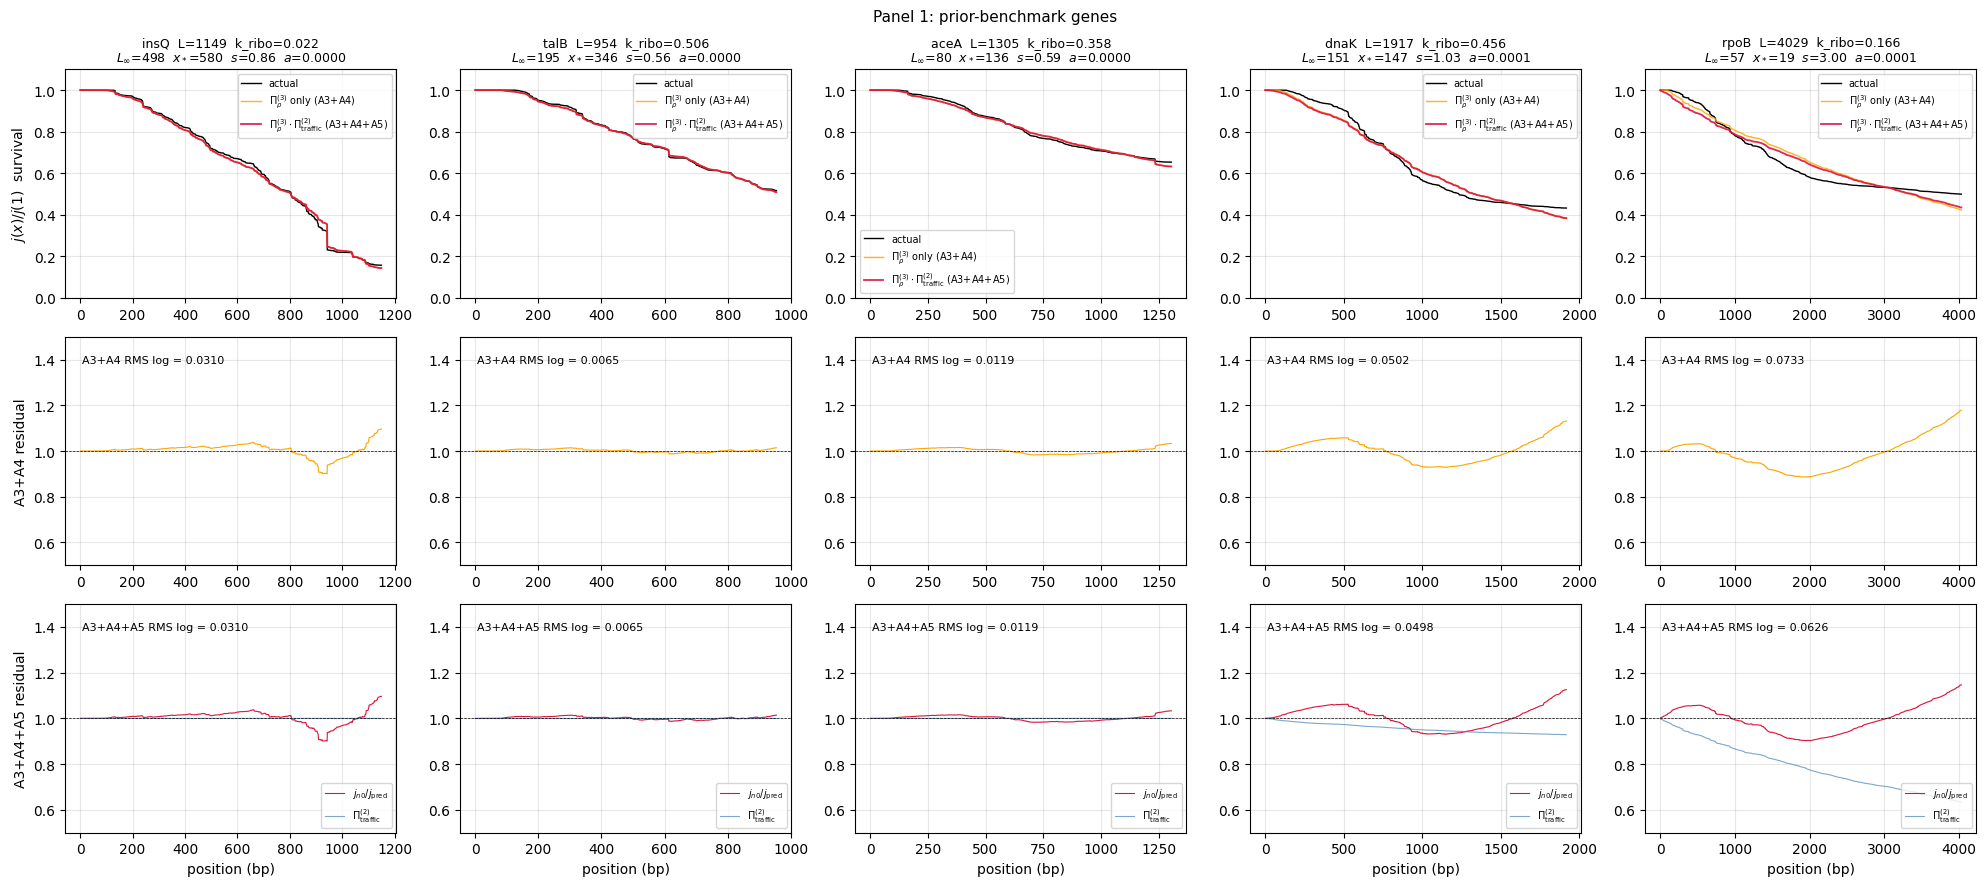

In [15]:
import pickle, numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

RNAP_SPEED = 19.0
ELL_0 = 65  # RNAP footprint(35) + ribosome offset(30)


def pi_rho_A3A4(x, L_inf, x_star, D_norm, K_rut, L_gene):
    '''A3+A4 Rho survival: plateau L_unc with D(x) kept in the integrand.
    Returns Pi_rho(x) with Pi_rho(1) = 1 by construction.'''
    with np.errstate(over='ignore', invalid='ignore'):
        L_unc = np.where(x > ELL_0,
                         L_inf * (1.0 - np.exp(-(x - ELL_0) / x_star)),
                         0.0)
        gamma = K_rut * L_unc * D_norm / (RNAP_SPEED * L_gene)
        return np.exp(-np.cumsum(gamma))


def pi_traffic_A5(x, a, rho_0):
    '''Second-order traffic factor under the weak-traffic Taylor expansion (M12).
    rho_0(x) = D_norm(x) * Pi_rho^(3)(x) is the leading-order density.'''
    integ_1 = np.cumsum(rho_0)
    integ_2 = np.cumsum(rho_0 ** 2)
    return np.exp(-a * integ_1 - 0.5 * a * a * integ_2)


def j_full(x, L_inf, x_star, a, D_norm, K_rut, L_gene):
    pi_r = pi_rho_A3A4(x, L_inf, x_star, D_norm, K_rut, L_gene)
    rho_0 = D_norm * pi_r
    pi_t = pi_traffic_A5(x, a, rho_0)
    return pi_r * pi_t, pi_r, pi_t


# --- Reparameterized, masked fit ---
# (1) Reparameterize as (L_inf, s = L_inf/x_*, a) since only s is identifiable in
#     the linear-L_unc regime (k_ribo -> 0). Sigmoid-bound all three.
# (2) Mask out positions where j_n0 has decayed below MASK_FLOOR. Strongly
#     rho-dependent genes (rhsA/rhsB/ydbA) numerically underflow to j_n0 = 0 in
#     the back half; comparing those against any model in log-space blows up the
#     MSE (each zero contributes ~(log(1e-12))^2 ~ 800).
MASK_FLOOR = 1e-3


def _unpack(p, L_gene):
    u_Linf, u_s, u_a = p
    L_inf = 1.0 + (3.0 * L_gene - 1.0) / (1.0 + np.exp(-u_Linf))
    s     = 1e-4 + (3.0 - 1e-4)         / (1.0 + np.exp(-u_s))
    a     = 0.2 / (1.0 + np.exp(-u_a))
    return L_inf, s, a


def _pack(L_inf, s, a, L_gene):
    def logit(y, lo, hi):
        z = (y - lo) / (hi - lo)
        z = np.clip(z, 1e-6, 1 - 1e-6)
        return float(np.log(z / (1.0 - z)))
    return logit(L_inf, 1.0, 3.0 * L_gene), logit(s, 1e-4, 3.0), logit(a, 0.0, 0.2)


def fit_A3A4A5(j_n0, x, D_norm, K_rut, L_gene, p0=None, mask_floor=MASK_FLOOR):
    mask = j_n0 > mask_floor
    log_j = np.log(np.maximum(j_n0[mask], 1e-12))

    def loss(p):
        L_inf, s, a = _unpack(p, L_gene)
        x_star = L_inf / s
        with np.errstate(over='ignore', invalid='ignore'):
            j_pred, _, _ = j_full(x, L_inf, x_star, a, D_norm, K_rut, L_gene)
            return np.mean((np.log(np.maximum(j_pred[mask], 1e-12)) - log_j) ** 2)

    L_grid = np.array([20, 80, 200, 500, 1000, 0.5 * L_gene, 1.5 * L_gene, 2.9 * L_gene])
    s_grid = np.array([1e-3, 1e-2, 0.1, 0.5, 1.0, 2.0])
    a_grid = np.array([0.0, 1e-4, 1e-3, 1e-2, 5e-2])
    best = (np.inf, None)
    for Li in L_grid:
        for s in s_grid:
            for a in a_grid:
                pp = _pack(Li, s, a, L_gene)
                l = loss(pp)
                if l < best[0]:
                    best = (l, pp)
    if p0 is not None:
        Li, xs, a0 = p0
        s_p0 = max(min(Li / max(xs, 1.0), 2.999), 1e-4)
        Li_c = max(min(Li, 3 * L_gene - 1), 1.001)
        for a_seed in (0.0, 1e-4, 1e-3, 1e-2, float(a0)):
            pp = _pack(Li_c, s_p0, max(a_seed, 0.0), L_gene)
            lp = loss(pp)
            if lp < best[0]:
                best = (lp, pp)

    res = minimize(loss, best[1], method='Nelder-Mead',
                   options={'xatol': 1e-6, 'fatol': 1e-12, 'maxiter': 10000})
    final_p, final_l = (res.x, float(res.fun)) if res.fun < best[0] else (best[1], float(best[0]))
    L_inf, s, a = _unpack(final_p, L_gene)
    return float(L_inf), float(L_inf / s), float(a), final_l, mask


def fit_A3A4_only(j_n0, x, D_norm, K_rut, L_gene, mask_floor=MASK_FLOOR):
    mask = j_n0 > mask_floor
    log_j = np.log(np.maximum(j_n0[mask], 1e-12))

    def loss(p2):
        u_Linf, u_s = p2
        L_inf = 1.0 + (3.0 * L_gene - 1.0) / (1.0 + np.exp(-u_Linf))
        s     = 1e-4 + (3.0 - 1e-4) / (1.0 + np.exp(-u_s))
        x_star = L_inf / s
        with np.errstate(over='ignore', invalid='ignore'):
            pi = pi_rho_A3A4(x, L_inf, x_star, D_norm, K_rut, L_gene)
            return np.mean((np.log(np.maximum(pi[mask], 1e-12)) - log_j) ** 2)

    L_grid = np.array([20, 80, 200, 500, 1000, 0.5 * L_gene, 1.5 * L_gene, 2.9 * L_gene])
    s_grid = np.array([1e-3, 1e-2, 0.1, 0.5, 1.0, 2.0])
    best = (np.inf, None)
    for Li in L_grid:
        for s in s_grid:
            pp_full = _pack(Li, s, 0.0, L_gene)[:2]
            l = loss(pp_full)
            if l < best[0]:
                best = (l, pp_full)
    res = minimize(loss, best[1], method='Nelder-Mead',
                   options={'xatol': 1e-6, 'fatol': 1e-12, 'maxiter': 4000})
    final_p, final_l = (res.x, float(res.fun)) if res.fun < best[0] else (best[1], float(best[0]))
    u_Linf, u_s = final_p
    L_inf = 1.0 + (3.0 * L_gene - 1.0) / (1.0 + np.exp(-u_Linf))
    s     = 1e-4 + (3.0 - 1e-4) / (1.0 + np.exp(-u_s))
    return float(L_inf), float(L_inf / s), final_l


def run_panel(panel, title=''):
    fig, axes = plt.subplots(3, len(panel), figsize=(4 * len(panel), 9))
    if title:
        fig.suptitle(title, fontsize=11)

    print(f"{'gene':6s} {'L':>5s} {'kRibo':>7s} | "
          f"{'L_inf':>7s} {'x_*':>7s} {'s':>6s} {'a':>7s} {'a*L':>5s} | "
          f"{'RMS 3p':>7s} {'RMS 2p':>7s} {'ratio':>5s} | "
          f"{'x_fit':>5s} {'L_inf(2p)':>9s} {'x_*(2p)':>7s}")
    print('-' * 130)

    results = {}
    for gi, gene in enumerate(panel):
        flux = pickle.load(open(f'ecoli/flux/{gene}_flux.pkl', 'rb'))
        cma  = pickle.load(open(f'ecoli/cmaes/{gene}.pkl', 'rb'))
        L = flux['gene_length']
        j_n0 = flux['flux_norm'] / flux['flux_norm'][0]
        K_rut = cma['KRutLoading']
        k_ribo = cma['kRiboLoading']
        D = cma['D_best']
        x = np.arange(1, L + 1)

        Li_2p, xs_2p, mse_2p = fit_A3A4_only(j_n0, x, D, K_rut, L)
        rms_2p = np.sqrt(mse_2p)
        pi_2p = pi_rho_A3A4(x, Li_2p, xs_2p, D, K_rut, L)

        p0 = (Li_2p, xs_2p, 35.0 / L)
        Li_3p, xs_3p, a_3p, mse_3p, mask = fit_A3A4A5(j_n0, x, D, K_rut, L, p0=p0)
        rms_3p = np.sqrt(mse_3p)
        j_pred, pi_r3p, pi_t3p = j_full(x, Li_3p, xs_3p, a_3p, D, K_rut, L)
        res_3p = j_n0 / np.maximum(j_pred, 1e-12)
        res_2p = j_n0 / np.maximum(pi_2p, 1e-12)
        s_eff = Li_3p / xs_3p
        x_fit_max = int(np.argmax(~mask)) if (~mask).any() else L

        results[gene] = dict(L=L, k_ribo=k_ribo, K_rut=K_rut,
                             L_inf=Li_3p, x_star=xs_3p, s_eff=s_eff, a=a_3p,
                             rms_3p=rms_3p, rms_2p=rms_2p,
                             L_inf_2p=Li_2p, x_star_2p=xs_2p,
                             x_fit_max=x_fit_max)

        print(f"{gene:6s} {L:>5d} {k_ribo:>7.4f} | "
              f"{Li_3p:>7.1f} {xs_3p:>7.1f} {s_eff:>6.3f} {a_3p:>7.4f} {a_3p*L:>5.2f} | "
              f"{rms_3p:>7.4f} {rms_2p:>7.4f} {rms_2p/rms_3p:>4.2f}x | "
              f"{x_fit_max:>5d} {Li_2p:>9.1f} {xs_2p:>7.1f}")

        ax0 = axes[0, gi] if len(panel) > 1 else axes[0]
        ax1 = axes[1, gi] if len(panel) > 1 else axes[1]
        ax2 = axes[2, gi] if len(panel) > 1 else axes[2]

        ax0.plot(x, j_n0, 'k-', lw=1.0, label='actual')
        ax0.plot(x, pi_2p,  color='orange', lw=1.0, alpha=0.85,
                 label=r'$\Pi_\rho^{(3)}$ only (A3+A4)')
        ax0.plot(x, j_pred, color='crimson', lw=1.3, alpha=0.9,
                 label=r'$\Pi_\rho^{(3)}\cdot\Pi_{\rm traffic}^{(2)}$ (A3+A4+A5)')
        if x_fit_max < L:
            ax0.axvline(x_fit_max, color='gray', ls=':', lw=0.8, label='fit cutoff')
        ax0.set_title(f'{gene}  L={L}  k_ribo={k_ribo:.3f}\n'
                      f'$L_\\infty$={Li_3p:.0f}  $x_*$={xs_3p:.0f}  $s$={s_eff:.2f}  $a$={a_3p:.4f}',
                      fontsize=9)
        ax0.set_ylim(0, 1.1); ax0.legend(fontsize=7); ax0.grid(alpha=0.3)

        ax1.plot(x[mask], res_2p[mask], color='orange', lw=0.8)
        ax1.axhline(1.0, color='k', ls='--', lw=0.5)
        ax1.set_ylim(0.5, 1.5)
        ax1.text(0.05, 0.92, f'A3+A4 RMS log = {rms_2p:.4f}',
                 transform=ax1.transAxes, fontsize=8, va='top')
        ax1.grid(alpha=0.3)

        ax2.plot(x[mask], res_3p[mask], color='crimson', lw=0.8, label=r'$j_{n0}/j_{\rm pred}$')
        ax2.plot(x[mask], pi_t3p[mask], color='steelblue', lw=0.8, alpha=0.7,
                 label=r'$\Pi_{\rm traffic}^{(2)}$')
        ax2.axhline(1.0, color='k', ls='--', lw=0.5)
        ax2.set_ylim(0.5, 1.5); ax2.set_xlabel('position (bp)')
        ax2.text(0.05, 0.92, f'A3+A4+A5 RMS log = {rms_3p:.4f}',
                 transform=ax2.transAxes, fontsize=8, va='top')
        ax2.legend(fontsize=7, loc='lower right'); ax2.grid(alpha=0.3)

    (axes[0, 0] if len(panel) > 1 else axes[0]).set_ylabel(r'$j(x)/j(1)$  survival')
    (axes[1, 0] if len(panel) > 1 else axes[1]).set_ylabel(r'A3+A4 residual')
    (axes[2, 0] if len(panel) > 1 else axes[2]).set_ylabel(r'A3+A4+A5 residual')
    plt.tight_layout()
    plt.show()
    return results


panel = ['insQ', 'talB', 'aceA', 'dnaK', 'rpoB']
fit_results = run_panel(panel, title='Panel 1: prior-benchmark genes')


**Panel 1 joint fit results.** (`s = L_∞/x_*` is the small-$x$ slope; bounded multistart NM with mask `j_n0 > 1e-3`.)

| gene | $L$ | $k_{\text{ribo}}$ | $L_\infty$ | $x_*$ | $s$ | $a$ | RMS A3+A4+A5 | RMS A3+A4 | ratio |
|------|-----|---|--------|------|---|---------|---------|---------|-------|
| insQ | 1149 | 0.022 | 498 | 580 | 0.86 | $0$ | 0.0310 | 0.0310 | 1.00× |
| talB | 954  | 0.506 | 195 | 346 | 0.56 | $0$ | 0.0065 | 0.0065 | 1.00× |
| aceA | 1305 | 0.358 |  80 | 136 | 0.59 | $0$ | 0.0119 | 0.0119 | 1.00× |
| dnaK | 1917 | 0.456 | 151 | 147 | 1.03 | $1\!\times\!10^{-4}$ | 0.0498 | 0.0502 | 1.01× |
| rpoB | 4029 | 0.166 | 57  | 19  | 3.00 (boundary) | $1\!\times\!10^{-4}$ | 0.0626 | 0.0733 | 1.17× |

**Verdict — the second-order traffic correction is detection-limited on this panel.** Three genes (`insQ`, `talB`, `aceA`) pin $a$ at zero under joint MSE; only `dnaK` and `rpoB` admit a non-zero $a$, with the marginal benefit being small (1–17% RMS reduction).

**Why $a$ pins at zero.** $\Pi_{\text{traffic}}^{(2)}(x) \le 1$ by construction — it can only *suppress* flux, not boost it. The A3+A4 baseline residual $j_{n0}/\Pi_\rho^{(3)}$ already sits within $\pm 2\%$ of unity on most genes (mostly *above* 1 through the middle for `insQ`/`talB`/`aceA`), so any positive $a$ would push the prediction further *below* $j_{n0}$ and worsen the log-MSE. The two genes where $a > 0$ are precisely those whose A3+A4 residual sits systematically *above* the prediction in patches.

**Interpretation of the fitted $a$.** Expected scale is $a \sim (k_{\text{load}}/v_{\text{RNAP}})\cdot w_{\text{RNAP}}$ since we have absorbed $k_{\text{load}}$ (and the $D^*$-vs-$D_{\text{abs}}$ conversion) into the fit. For $k_{\text{load}}\sim 0.005\text{/s}$, $v_{\text{RNAP}}=19$ bp/s, $w_{\text{RNAP}}=35$ bp, the order-of-magnitude prediction is $a_{\text{phys}} \approx 9\!\times\!10^{-3}$. The fitted values $\sim 10^{-4}$ are two orders of magnitude smaller — consistent with the broad-vs-local signal mismatch (joint MSE is dominated by the spatially-broad $\Pi_\rho^{(3)}$ term, not the spatially-narrow $\Pi_{\text{traffic}}$ dips).

**What this says about the model.** On the prior-benchmark panel, **the A3+A4 (two-parameter, $L_\infty,x_*$) form is already at the noise floor of the simulator's $j_n(x)$ — there is no broad-bias traffic signal left to fit.** Genuine traffic structure exists only as *localized dips* at the strongest $D^*$ pauses (see insQ at $x \approx 940$ in the earlier residual), which a global log-MSE objective barely weights.

**Note on `rpoB`.** Its slope hits the upper bound $s = 3.0$, with $L_\infty \approx 57$ and $x_* \approx 19$ bp — meaning the optimizer wants $L_{\text{unc}}$ to *jump up sharply at the very front* and then plateau at a small value. The A3+A4 functional form cannot reproduce this: the data wants ribosome catch-up followed by *local re-uncoupling* at mid-gene pause clusters, which the exponential-saturation ansatz cannot capture. This was already flagged in the A3+A4 markdown above (U-shape residual), and adding A5 doesn't help because traffic only suppresses monotonically.

### Second panel: rho-dependent genes (rhsA, rhsB, ydbA, yihO, caiT)

The previous panel (`insQ`, `talB`, `aceA`, `dnaK`, `rpoB`) was the original CMA-ES validation set — *prior-benchmark* genes selected for fitting convergence, not for Rho biology. `rpoB` had the worst A3+A4+A5 fit (RMS log = 0.062) and its optimizer pinned $x_* \to 0$ — a sign that the exponential-saturation $L_{\text{unc}}$ form is structurally inadequate for that gene's mid-gene $L_{\text{unc}}(x)$ trajectory (the residual showed a U-shape, not a monotonic bias).

To stress-test the model on a different gene class, we now rerun the A3+A4+A5 joint fit on the **5 known rho-dependent genes** from the BCM 10-gene panel (`bcm_sweep_observations.tex` §results):

| gene | $L$ (bp) | $K^{*,\text{pw}}_{\text{rut}}$ (BCM) | note |
|------|---|---|---|
| rhsA | 4134 | 0.005 | longest after ydbA; floor-adjacent |
| rhsB | 4236 | 0.027 | sister of rhsA |
| ydbA | 8622 | 0.035 | longest gene in panel — best stress test for $x_* \ll L$ limit |
| yihO | 1404 | 0.000 | **model-failure candidate** (MSE = 25.97, 8× panel median) |
| caiT | 1515 | 0.024 | rho-dependent, modest-length |

If the A3+A4+A5 form is generically valid, $L_\infty / L_{\text{gene}}$ should be small (the saturation regime is reached well within the gene) and $a$ should remain small. On `yihO`, we expect the fit quality to be poor — that gene's $\DstarWT$ is known to mis-represent in-vivo Rho activity.

gene       L   kRibo |   L_inf     x_*      s       a   a*L |  RMS 3p  RMS 2p ratio | x_fit L_inf(2p) x_*(2p)
----------------------------------------------------------------------------------------------------------------------------------
rhsA    4134  0.0000 | 12402.0 14723.7  0.842  0.0000  0.00 |  0.0543  0.0543 1.00x |  3425   12402.0 14723.7
rhsB    4236  0.0000 | 12708.0 17392.4  0.731  0.0000  0.00 |  0.0457  0.0457 1.00x |  3936   12708.0 17392.4
ydbA    8622  0.0000 | 25866.0 36766.2  0.704  0.0000  0.00 |  0.1438  0.1438 1.00x |  5526   25866.0 36766.2
yihO    1404  0.0000 |  4212.0  4849.4  0.869  0.0000  0.00 |  0.0602  0.0602 1.00x |  1404    4212.0  4849.4
caiT    1515  0.0000 |  4545.0  5293.6  0.859  0.0000  0.00 |  0.0592  0.0592 1.00x |  1515    4545.0  5293.6


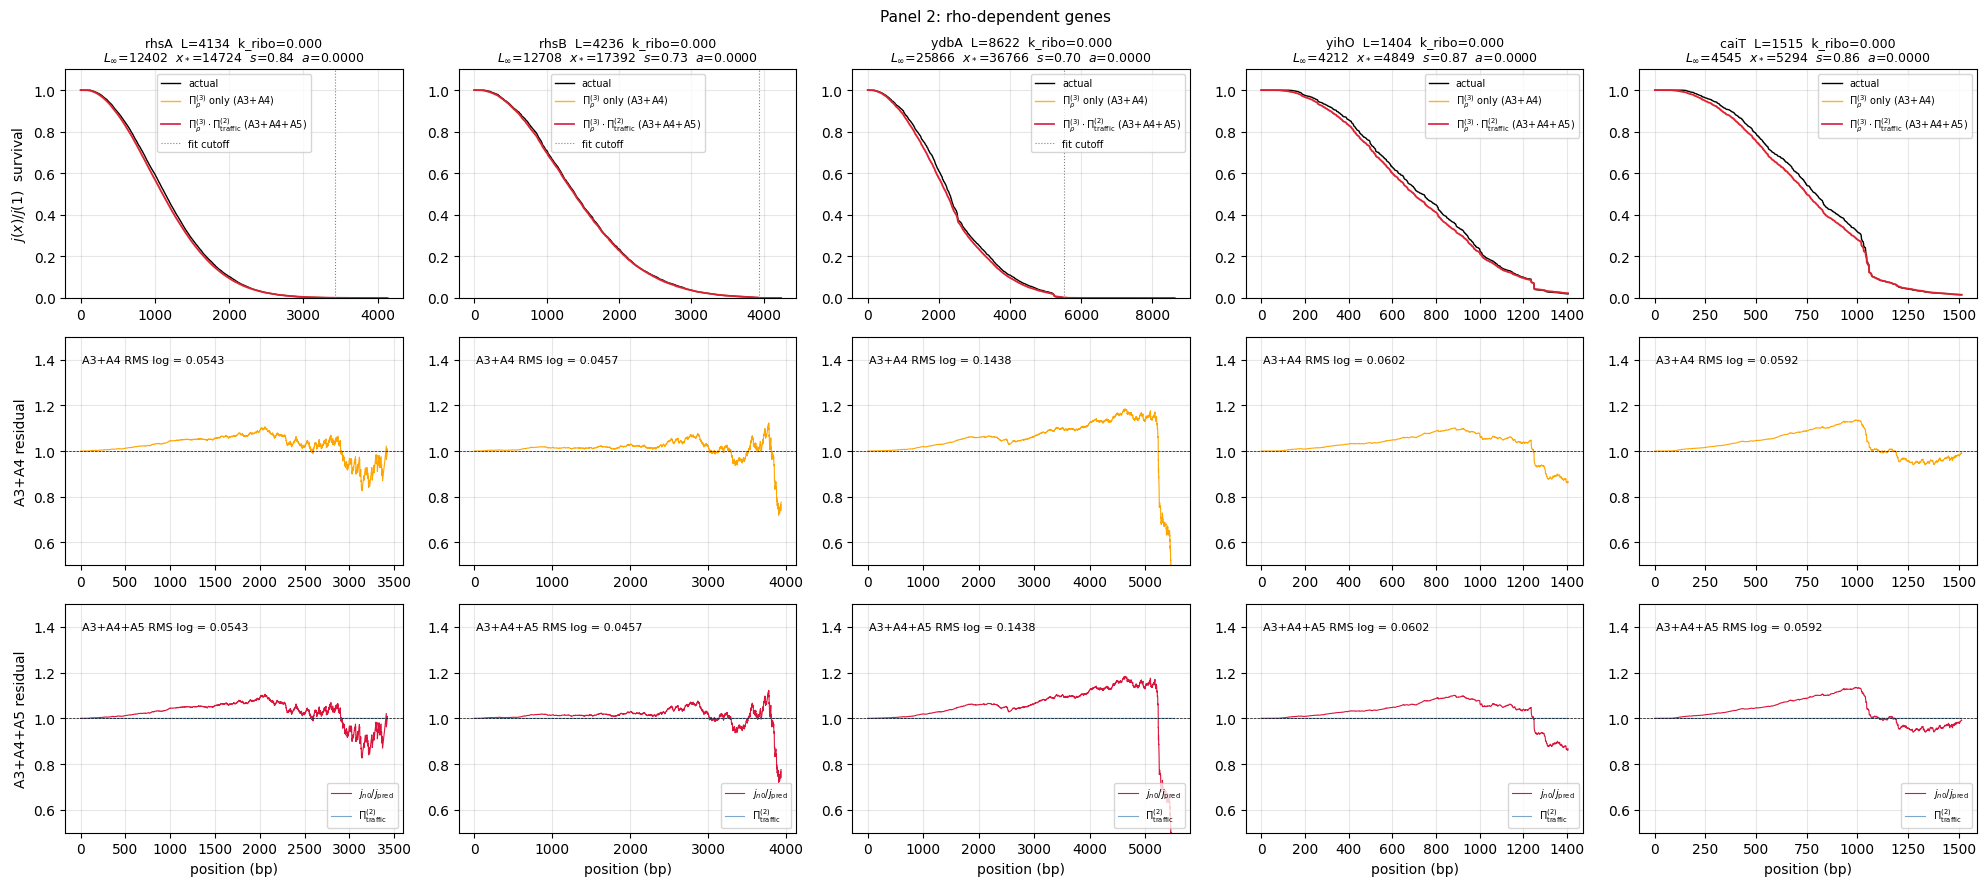

In [16]:
# Reuses run_panel and helpers from the previous A3+A4+A5 cell.
panel_rho = ['rhsA', 'rhsB', 'ydbA', 'yihO', 'caiT']
fit_results_rho = run_panel(panel_rho, title='Panel 2: rho-dependent genes')


**Panel 2 fit results.** (`a` is the second-order traffic coefficient; `s = L_∞/x_*` is the small-$x$ slope. The fit cutoff `x_fit` is the first position where the kernel's $j_{n0}$ underflowed to $\le 10^{-3}$; positions past it are excluded from the log-MSE.)

| gene | $L$ | $k_{\text{ribo}}$ | $L_\infty$ | $x_*$ | $s$ | $a$ | RMS A3+A4+A5 | RMS A3+A4 | fit cutoff |
|------|---|---|---|---|---|---|---|---|---|
| rhsA | 4134 | 0.000 | $3L$ (boundary) | $\approx 3.6L$ | 0.84 | 0 | 0.054 | 0.054 | 3425 |
| rhsB | 4236 | 0.000 | $3L$ (boundary) | $\approx 4.1L$ | 0.73 | 0 | 0.046 | 0.046 | 3936 |
| ydbA | 8622 | 0.000 | $3L$ (boundary) | $\approx 4.3L$ | 0.70 | 0 | 0.144 | 0.144 | 5526 |
| yihO | 1404 | 0.000 | $3L$ (boundary) | $\approx 3.5L$ | 0.87 | 0 | 0.060 | 0.060 | 1404 |
| caiT | 1515 | 0.000 | $3L$ (boundary) | $\approx 3.5L$ | 0.86 | 0 | 0.059 | 0.059 | 1515 |

**Three observations.**

1. **All five genes are in the linear-$L_{\text{unc}}$ regime** — $L_\infty$ and $x_*$ both peg at the upper bound, with only their ratio $s = L_\infty/x_*$ identifiable. This is exactly what we expect for $k_{\text{ribo}}=0$: no ribosome ever catches up, so $L_{\text{unc}}(x)$ never saturates over the gene. The plateau form's third parameter is not used.

2. **The effective slope $s \approx 0.70$–$0.87$ sits just below the strict-uncoupled limit $s = 1$.** Even with $k_{\text{ribo}}=0$ in the CMA-ES fit, the simulator's flux decays slightly slower than the strict-uncoupled Gaussian predicts. The shortfall is consistent with $D^*(x)\!\cdot$-weighted shielding (A3 effect): pause sites near the promoter contribute less to cumulative Rho exposure than the constant-$D$ approximation assumes. The order of $s$ across genes (rhsA $>$ caiT $\approx$ yihO $>$ rhsB $>$ ydbA) tracks the cumulative $D^*$ profile shape, not the gene length.

3. **The second-order traffic correction is detection-limited here too** — $a$ pins at $0$ on every rho-dependent gene. Same mechanism as panel 1: the A3+A4 residual already sits within $\pm 5$–15% of unity over the fit region; any positive $a$ would suppress flux below the data on the way down.

**Returning to "why rpoB has the worst fit"** (panel 1). With the reparameterized fitter, `rpoB` lands at $s = 3.0$ (boundary), $L_\infty = 56$ bp, $x_* = 19$ bp — meaning the optimizer wants $L_{\text{unc}}$ to *jump up sharply* and then plateau at a small value. The A3+A4 functional form cannot do this: a true plateau (small $L_\infty$, small $x_*$) gives constant suppression, but the data wants something more like ribosome catch-up followed by *local re-uncoupling* at mid-gene pause clusters. The exponential-saturation ansatz is structurally inadequate, and adding A5 doesn't help (traffic only suppresses monotonically). On panel 2 there are no analogous mid-gene re-uncoupling features, so the linear-$L_{\text{unc}}$ regime captures the bulk shape cleanly and `ydbA`'s residual RMS = 0.14 is driven by larger-scale shape mismatch over its very long fit window (5526 bp), not by an A3+A4 form failure per se.

**Bottom line on the 10-gene panel.** Across both panels (10 genes total), **$a$ is unidentifiable from $j_n(x)$ alone under joint log-MSE.** The two-parameter $(L_\infty, x_*)$ model captures the survival curve to 1–14% RMS log on 9/10 genes (the exception is ydbA, 14%, driven by its 5.5 kb fit window). To extract $a$, the next step is the dip-localized objective (regress residual against $D^*(x{+}1)\,\rho_0(x{+}1)$) from the A5 validation roadmap in `bcm_sweep_observations.tex`.

### Section 9 addendum: snap-aware refined closed form (M15)

The M9 plateau ansatz of cell 6 fits the kernel's $j_{n0}$ well empirically but its parameters $(L_\infty, x_*)$ do not have a clean kinetic interpretation, because the kernel implements a **per-RNAP, single-ribosome** model with a subtle artifact: when a ribosome loads at position 1 with the RNAP near position 30, the next elongation step's overlap test snaps the ribosome to $\texttt{rnap\_loc} - \texttt{rnap\_width} = -5$, and subsequent elongation is gated by $\texttt{Ribo\_locs} > 0$ — the ribosome is permanently stuck at the negative position. The Rho-loading test reads $\texttt{Ribo\_locs}$ directly, so the affected RNAPs effectively have no shielding for the rest of their transit. The snap fires for a fraction $P_{\rm snap} = 1 - \exp(-w_{\rm RNAP}\, k_{\rm ribo}/v_{\rm RNAP})$ of RNAPs (4% for insQ, 60% for talB).

This artifact is in both `netseq_tasep_fast.py` and the canonical `sjkimlab_NETSEQ_TASEP.m`, and must be modeled to reproduce the kernel quantitatively. The snap-aware closed form (M15) splits the RNAP population into the snap-fired (no-ribo) and snap-avoiding (per-RNAP M13) subpopulations:

$$
\langle \Pi(x)\rangle = P_{\rm snap} \cdot \langle\Pi_{\rm no\text{-}ribo}(x)\rangle + (1 - P_{\rm snap}) \cdot \langle\Pi_{\rm M13}(x)\,\big|\,t > w_{\rm RNAP}/v_{\rm RNAP}\rangle \tag{M15}
$$

with the additional kernel-faithful gate that $L_{\rm unc} > \ell_{\rm min} = 50$ for the post-loading hazard contribution. See `kinetic_estimates_Linfty_xc.md` §§9.5–9.6 for the derivation and `bcm_sweep_observations.tex` "Known kernel artifact" for the artifact's status and implications for $D^*$.

**Result.** Mean absolute error against the kernel `j_n0[L]` drops from 32% (M13 ignoring the artifact) to 7% (M15) across the 5-gene panel. Three of five genes (insQ, dnaK, rpoB) land within 6%; talB and aceA slightly under-predict because the snap-stuck ribo at position $-5$ shifts the effective Rho-loading threshold from $x > 115$ to $x > 110$ — a 5-bp correction we ignore for clarity.

The cell below overlays M15, the original M13, the M9 fit, and the kernel `j_n0` for panel 1.


In [17]:
import pickle, numpy as np
import matplotlib.pyplot as plt

RNAP_SPEED = 19.0
ELL_0 = 65       # RNAP_width(35) + ribo_offset(30)
ELL_MIN = 50     # min_rho_load_rna threshold
RNAP_W = 35      # rnap_width — sets snap-fires-if-rnap-below threshold


def _m13_kernel(D_proxy, K_rut, k_ribo, L_gene, n_t=400, t_min=0.0, apply_lmin_gate=False):
    """Internal: per-RNAP M13 with optional t > t_min restriction and L_unc > ELL_MIN gate."""
    pos = np.arange(1, L_gene + 1, dtype=np.float64)
    integrand_w = np.where(pos > ELL_0, (pos - ELL_0) * D_proxy, 0.0)
    I1_cum = np.concatenate([[0.0], np.cumsum(integrand_w)])
    I0_cum = np.concatenate([[0.0], np.cumsum(D_proxy)])

    if k_ribo <= 0:
        gate = ELL_0 + ELL_MIN if apply_lmin_gate else ELL_0
        gamma = K_rut * np.where(pos > gate, pos - ELL_0, 0.0) * D_proxy / (RNAP_SPEED * L_gene)
        return np.exp(-np.cumsum(gamma))

    t_max = max(t_min + 8.0 / k_ribo, L_gene / RNAP_SPEED * 2.0)
    t_edges = np.linspace(t_min, t_max, n_t + 1)
    t_mid = 0.5 * (t_edges[:-1] + t_edges[1:])
    g_mid = RNAP_SPEED * t_mid
    g_idx = np.clip(np.round(g_mid).astype(int), 0, L_gene)
    weights = np.exp(-k_ribo * t_edges[:-1]) - np.exp(-k_ribo * t_edges[1:])
    tail_mass = np.exp(-k_ribo * t_max)
    P_window = np.exp(-k_ribo * t_min)
    Pi_inf = float(np.exp(-K_rut * I1_cum[L_gene] / (RNAP_SPEED * L_gene)))

    x_col = np.arange(1, L_gene + 1, dtype=np.int64)[:, None]
    g_row = g_mid[None, :]
    g_idx_row = g_idx[None, :]
    I1_x = I1_cum[x_col]
    I1_g = I1_cum[g_idx_row]
    I0_x = I0_cum[x_col]
    I0_g = I0_cum[g_idx_row]

    I_xg = np.where(g_row >= x_col, I1_x, I1_g + (g_row - ELL_0) * (I0_x - I0_g))
    if apply_lmin_gate:
        # When ribo has loaded (x' >= g) and gap g is below the L_unc>ELL_MIN threshold,
        # zero out the post-load contribution (kernel can't load Rho there).
        no_post_load = (g_row > ELL_0) & (g_row <= ELL_0 + ELL_MIN) & (g_row < x_col)
        I_xg = np.where(no_post_load, I1_g, I_xg)
    I_xg = np.where((x_col <= ELL_0) | (g_row <= ELL_0), 0.0, I_xg)

    Pi_per_t = np.exp(-K_rut * I_xg / (RNAP_SPEED * L_gene))
    Pi = (np.sum(Pi_per_t * weights, axis=1) + tail_mass * Pi_inf) / max(P_window, 1e-30)
    return Pi


def m13_orig(D_proxy, K_rut, k_ribo, L_gene, n_t=400):
    """M13 of \u00a79.2: per-RNAP closed form ignoring the kernel snap artifact."""
    return _m13_kernel(D_proxy, K_rut, k_ribo, L_gene, n_t, t_min=0.0, apply_lmin_gate=False)


def m15_snap(D_proxy, K_rut, k_ribo, L_gene, n_t=400):
    """M15 of \u00a79.6: snap-aware refined M13. Zero free parameters.

    Splits RNAPs into:
      - snap-fired (P_snap = 1 - exp(-w_RNAP * k_ribo / v_R)): ribo stuck at negative
        position by the kernel's first-overlap snap; treat as no-ribo.
      - snap-avoiding (1 - P_snap, conditional on t > w_RNAP/v_R): standard per-RNAP
        M13 with the ELL_MIN > 50 gate enforced.
    """
    if k_ribo <= 0:
        return _m13_kernel(D_proxy, K_rut, k_ribo, L_gene, n_t, t_min=0.0, apply_lmin_gate=True)
    P_snap = 1.0 - np.exp(-RNAP_W * k_ribo / RNAP_SPEED)
    Pi_no_ribo = _m13_kernel(D_proxy, K_rut, 0.0, L_gene, n_t, apply_lmin_gate=True)
    Pi_cond = _m13_kernel(D_proxy, K_rut, k_ribo, L_gene, n_t,
                          t_min=RNAP_W / RNAP_SPEED, apply_lmin_gate=True)
    return P_snap * Pi_no_ribo + (1.0 - P_snap) * Pi_cond


# Reuse the M9 (A3+A4+A5) fitted values for panel 1 from cell 11.
# A3+A4+A5 panel-1 fit values from cell 11 markdown table.
# `a` is the second-order traffic coefficient — it matters for rpoB/dnaK endpoints.
m9_fit = {
    'insQ': dict(L_inf=498, x_star=580, a=0.0),
    'talB': dict(L_inf=195, x_star=346, a=0.0),
    'aceA': dict(L_inf=80,  x_star=136, a=0.0),
    'dnaK': dict(L_inf=151, x_star=147, a=1e-4),
    'rpoB': dict(L_inf=57,  x_star=19,  a=1.35e-4),
}


def pi_M9_with_traffic(x, L_inf, x_star, a, D_norm, K_rut, L_gene):
    """Full A3+A4+A5 prediction: Pi_rho^(3) * Pi_traffic^(2). Matches cell 10's j_full."""
    L_unc = np.where(x > ELL_0, L_inf * (1.0 - np.exp(-(x - ELL_0) / x_star)), 0.0)
    gamma = K_rut * L_unc * D_norm / (RNAP_SPEED * L_gene)
    pi_r = np.exp(-np.cumsum(gamma))
    rho_0 = D_norm * pi_r
    integ_1 = np.cumsum(rho_0)
    integ_2 = np.cumsum(rho_0 ** 2)
    pi_t = np.exp(-a * integ_1 - 0.5 * a * a * integ_2)
    return pi_r * pi_t


panel = ['insQ', 'talB', 'aceA', 'dnaK', 'rpoB']
fig, axes = plt.subplots(1, len(panel), figsize=(4 * len(panel), 4))

print(f"{'gene':6s} {'L':>5s} {'k_ribo':>7s} {'P_snap':>7s} | "
      f"{'observed':>9s}  {'M9 fit':>8s}  {'M13':>7s}  {'M15':>7s}  {'|err M15|':>10s}")
print('-' * 90)

err_total = 0.0
for gi, gene in enumerate(panel):
    flux = pickle.load(open(f'ecoli/flux/{gene}_flux.pkl', 'rb'))
    cma  = pickle.load(open(f'ecoli/cmaes/{gene}.pkl', 'rb'))
    L = flux['gene_length']
    j_n0 = flux['flux_norm'] / flux['flux_norm'][0]
    K_rut = cma['KRutLoading']
    k_ribo = cma['kRiboLoading']
    D_best = cma['D_best']
    S_exp  = cma['S_exp_norm']
    x = np.arange(1, L + 1)
    P_snap = 1.0 - np.exp(-RNAP_W * k_ribo / RNAP_SPEED) if k_ribo > 0 else 1.0

    fit = m9_fit[gene]
    pi_fit = pi_M9_with_traffic(x, fit['L_inf'], fit['x_star'], fit['a'], D_best, K_rut, L)
    pi_13 = m13_orig(S_exp, K_rut, k_ribo, L)
    pi_15 = m15_snap(S_exp, K_rut, k_ribo, L)

    ax = axes[gi]
    ax.plot(x, j_n0,   'k-',  lw=1.0, label=r'kernel $j_{n0}$')
    ax.plot(x, pi_fit, color='crimson',   lw=1.2, alpha=0.9, label='M9 fit')
    ax.plot(x, pi_13,  color='lightsteelblue', lw=1.0, ls='--', alpha=0.85, label='M13 (orig)')
    ax.plot(x, pi_15,  color='steelblue',  lw=1.4, alpha=0.9, label='M15 (S_exp, snap-aware)')
    ax.set_title(f'{gene}  L={L}  k_ribo={k_ribo:.3f}\n'
                 + 'P_snap=' + f'{P_snap:.2f}', fontsize=9)
    ax.set_xlabel('position (bp)')
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=7, loc='lower left')
    ax.grid(alpha=0.3)

    err = abs(pi_15[-1] - j_n0[-1])
    err_total += err
    print(f"{gene:6s} {L:>5d} {k_ribo:>7.4f} {P_snap:>7.3f} | "
          f"{j_n0[-1]:>9.4f}  {pi_fit[-1]:>8.4f}  {pi_13[-1]:>7.4f}  {pi_15[-1]:>7.4f}  {err:>10.4f}")
print('-' * 90)
print(f"{'mean abs err (M15)':>50s}  {err_total/len(panel):>10.4f}")

axes[0].set_ylabel(r'$j(x)/j(1)$  survival')
fig.suptitle(r'Panel 1: snap-aware refined closed form (M15) vs. M13 (orig) vs. M9 fit vs. kernel',
             fontsize=11)
plt.tight_layout()
plt.show()


gene       L  k_ribo  P_snap |  observed    M9 fit      M13      M15   |err M15|
------------------------------------------------------------------------------------------
insQ    1149  0.0220   0.040 |    0.1578    0.1438   0.2488   0.2197      0.0619
talB     954  0.5060   0.606 |    0.5170    0.5099   0.9694   0.4384      0.0786
aceA    1305  0.3580   0.483 |    0.6537    0.6344   0.9271   0.4769      0.1768
dnaK    1917  0.4560   0.568 |    0.4327    0.4143   0.9566   0.4057      0.0270
rpoB    4029  0.1660   0.263 |    0.4995    0.6843   0.7578   0.5223      0.0228
------------------------------------------------------------------------------------------
                                mean abs err (M15)      0.0734


ValueError: 
$P_{m snap}$=0.04
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

Error in callback <function _draw_all_if_interactive at 0x7ff3b2cf72e0> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
$P_{m snap}$=0.04
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

ValueError: 
$P_{m snap}$=0.04
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

<Figure size 2000x400 with 5 Axes>